In [ ]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Here we are considereing rotated surface code with distance d=3. Let's assume data qubits and ancilla qubits placed as below diagram.

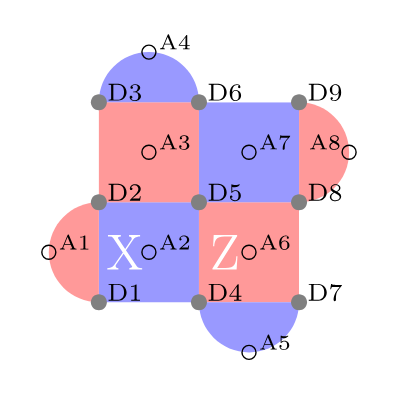

Fig: The qubit layout of a distance-3 rotated surface code, where data qubits are on the vertices (solid circles) and X- and Z-ancilla qubits are on the purple and pink plaquettes (open circles), respectively.

Data: D1–D9, Ancilla: A1–A8

Grid layout (row, col), spacing:

D3=(0,0)  
D6=(0,1)  
D9=(0,2)  
D2=(1,0)  
D5=(1,1)  
D8=(1,2)  
D1=(2,0)  
D4=(2,1)  
D7=(2,2)
  

---


  
  X stabilizers (purple faces) — 2 interior + 2 boundary:

A2: [D2, D5, D1, D4]  (weight-4)

A7: [D6, D9, D5, D8]  (weight-4)

A4: [D3, D6] (top left boundary, weight-2)

A5: [D4, D7] (bottom right boundary, weight-2)


---



Z stabilizers (pink faces) — 2 interior + 2 boundary:

A3: [D3, D6, D2, D5]  (weight-4)

A6: [D5, D8, D4, D7]  (weight-4)

A1: [D1, D2] (bottom left boundary, weight -2)

A8: [D9, D8] (top-right boundary, weight-2)

In [ ]:
#Data qubits: → D1..D9
D = QuantumRegister(9, 'D')

# Ancilla qubits:→ A1..A8
A = QuantumRegister(8, 'A')

# Syndrome classical bits: s[0]..s[7] correspond to A1..A8
S = ClassicalRegister(8, 's')

qc = QuantumCircuit(D, A, S)

\|0⟩$_L$

# Step1:
Encoding logical-|0⟩ or |0⟩$_L$ state.




In [ ]:
# All data qubits default to |0⟩. No prep neeeded for logical |0⟩ here.
qc.barrier(label="|0⟩_L encoded")
# qc.draw(output = 'mpl')


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

STEP additional:

Inject a test error


# Step 2:

Z-TYPE stabilizers (detect X/bit-flip errors)

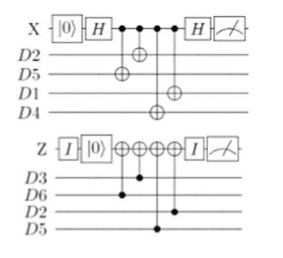

Fig: Error syndrome measurement circuits for X- and Z-stabilizers (X$_{D5, D2, D4, D1}$ and Z$_{D6, D3, D5, D2}$)

In [ ]:
# Z Stabilizer
# Protocol: ancilla starts |0>
#   CNOT(data_qubit (control) → ancilla(target)) for each neighbor
#   Measure ancilla → gives ZZ parity of neighbors

# Z Stabilizer    Ancilla    Data neighbors
#   Z(A3)        A[2]      D3,D6,D2,D5  = D[2],D[5],D[1],D[4]
#   Z(A6)        A[5]      D5,D8,D4,D7  = D[4],D[7],D[3],D[6]
#   Z(A1)        A[0]      D2,D1        = D[1],D[0]
#   Z(A8)        A[7]      D8,D9        = D[7],D[8]


# Z stabilizer A3: neighbors D3, D2, D6, D5
qc.cx(D[2], A[2])   # D3 → A3
qc.cx(D[1], A[2])   # D2 → A3
qc.cx(D[5], A[2])   # D6 → A3
qc.cx(D[4], A[2])   # D5 → A3
qc.measure(A[2], S[2])
qc.reset(A[2])

# Z stabilizer A6: neighbors D5, D4, D8, D7
qc.cx(D[4], A[5])   # D5 → A7
qc.cx(D[3], A[5])   # D4 → A7
qc.cx(D[7], A[5])   # D8 → A7
qc.cx(D[6], A[5])   # D7 → A7
qc.measure(A[5], S[5])
qc.reset(A[5])

# Z stabilizer A1: neighbors D2,D1
qc.cx(D[1], A[0])   # D2 → A1
qc.cx(D[0], A[0])   # D1 → A1
qc.measure(A[0], S[0])
qc.reset(A[0])

# Z stabilizer A8: neighbors D9, D8
qc.cx(D[8], A[7])   # D9 → A8
qc.cx(D[7], A[7])   # D8 → A8
qc.measure(A[7], S[7])
qc.reset(A[7])

qc.barrier(label="Z stabs done")
# qc.draw(output="mpl", fold = 1)

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

In [ ]:
# X stabilizers:
# Protocol: ancilla starts |+> (apply H)
#   CNOT(ancilla (control) → data_qubit(target)) for each neighbor
#   H on ancilla, then measure → gives XX parity of neighbors
#
# Boundary X stabilizers:
#   X(A2)  A[1]   D1, D4, D5, D2       = D[0], D[3], D[4], D[1]
#   X(A7)  A[6]   D6, D9, D5, D8       = D[5], D[8], D[4], D[7]
#   X(A4)  A[3]   D3, D6               = D[2], D[5]
#   X(A5)  A[4]   D4, D7               = D[3], D[6]

# X stabilizer A2: neighbors D2, D5, D1, D4
qc.h(A[1])
qc.cx(A[1], D[1])   # A2 → D2
qc.cx(A[1], D[4])   # A2 → D5
qc.cx(A[1], D[0])   # A2 → D1
qc.cx(A[1], D[3])   # A2 → D4
qc.h(A[1])
qc.measure(A[1], S[1])
qc.reset(A[1])

# X stabilizer A7: neighbors D6, D9, D5, D8
qc.h(A[6])
qc.cx(A[6], D[5])   # A7 → D6
qc.cx(A[6], D[8])   # A7 → D9
qc.cx(A[6], D[4])   # A7 → D5
qc.cx(A[6], D[7])   # A7 → D8
qc.h(A[6])
qc.measure(A[6], S[6])
qc.reset(A[6])

# X stabilizer A4: neighbors D3, D6
qc.h(A[3])
qc.cx(A[3], D[2])   # A4 → D3
qc.cx(A[3], D[5])   # A4 → D6
qc.h(A[3])
qc.measure(A[3], S[3])
qc.reset(A[3])

# X stabilizer A5: neighbors D4, D7
qc.h(A[4])
qc.cx(A[4], D[3])   # A5 → D4
qc.cx(A[4], D[6])   # A5 → D7
qc.h(A[4])
qc.measure(A[4], S[4])
qc.reset(A[4])

qc.barrier(label="X stabs done")
# qc.draw(output="mpl", fold =1)

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

In [ ]:
# --- Test: X error on D5 (center qubit) ---
# Should trigger Z stabilizers: A3, A6
# qc.x(D[4])

# --- Test: Z error on D5 ---
# Should trigger X stabilizers touching D5: A2, A7
qc.z(D[4])

qc.barrier(label="Test error")
# qc.draw(output = 'mpl')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

# STEP 4:
Syndrome measurement

In [ ]:
# Measure all ancilla into classical register
# s[0..7] → A1..A8

# qc.measure(A, S)

STEP 5:

Simulation

In [ ]:
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

In [ ]:
# Syndrome bit ordering: s[7]s[6]s[5]s[4]s[3]s[2]s[1]s[0]
#                         A8  A7  A6  A5  A4  A3  A2  A1
print("Syndrome results (A8 A7 A6 A5 A4 A3 A2 A1):")
for bits, count in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {bits}  ({count} shots)")

Syndrome results (A8 A7 A6 A5 A4 A3 A2 A1):
  01011000  (78 shots)
  00011010  (73 shots)
  00010010  (73 shots)
  00001010  (72 shots)
  01011010  (68 shots)
  00000010  (68 shots)
  01001010  (67 shots)
  00011000  (63 shots)
  01010000  (62 shots)
  01000010  (62 shots)
  01010010  (61 shots)
  00010000  (61 shots)
  00001000  (57 shots)
  01001000  (55 shots)
  01000000  (54 shots)
  00000000  (50 shots)


In [ ]:
# bits='11110000'
# b = bits[::-1]  # now b[0]=A1, b[1]=A2, ..., b[7]=A8
# A1,A2,A3,A4,A5,A6,A7,A8 = [int(x) for x in b]
# print(bits)
# print(b)
# print(b[0:4])
# print(A1,A2,A3,A4,A5,A6,A7,A8)

In [ ]:
# SYNDROME DECODE TABLE
# Maps ancilla flip pattern to most likely error
# ============================================================
def decode_syndrome(bits):
    # bits string is s[7..0] = A8 A7 A6 A5 A4 A3 A2 A1
    # Reverse to index A1=bits[7], A2=bits[6], ..., A8=bits[0]
    b = bits[::-1]  # now b[0]=A1, b[1]=A2, ..., b[7]=A8
    A1,A2,A3,A4,A5,A6,A7,A8 = [int(x) for x in b]

    # Z-stabilizer ancillas: A3(idx2), A6(idx5), A1(idx0), A8(idx7)
    # X-stabilizer ancillas: A2(idx1), A7(idx6), A4(idx3), A5(idx4)
    z_syn = (A3, A6, A1, A8)
    x_syn = (A2, A7, A4, A5)

    Zs_Xflip = {
        (0,0,0,0): "No Z-stab trigger",
        (0,0,0,1): "X error on D9",
        (0,0,1,0): "X error on D1",
        (0,0,1,1): "X error on D1 or D9",
        (0,1,0,0): "X error on D4 or D7",
        (0,1,0,1): "X error on D8",
        (0,1,1,0): "X error on D1",
        (0,1,1,1): "X error on D1 or D8",
        (1,0,0,0): "X error on D3 or D6",
        (1,0,0,1): "X error on D3 or D6 or D9",
        (1,0,1,0): "X error on D2",
        (1,0,1,1): "X error on D2 or D9",
        (1,1,0,0): "X error on D5",
        (1,1,0,1): "X error on D5 or D8",
        (1,1,1,0): "X error on D5 or D2",
        (1,1,1,1): "X error on D5 or D8 or D2"

    }
    Xs_Zflip = {
        (0,0,0,0): "No X-stab trigger",
        (0,0,0,1): "Z error on D7",
        (0,0,1,0): "Z error on D3",
        (0,0,1,1): "Z error on D3 or D7",
        (0,1,0,0): "Z error on D8 or D9",
        (0,1,0,1): "Z error on D9 or D8 or D7",
        (0,1,1,0): "Z error on D6",
        (0,1,1,1): "Z error on D6 or D7",
        (1,0,0,0): "Z error on D1 or D2",
        (1,0,0,1): "Z error on D4",
        (1,0,1,0): "Z error on D1 or D2 or D3",
        (1,0,1,1): "Z error on D3 or D4",
        (1,1,0,0): "Z error on D5",
        (1,1,0,1): "Z error on D4 or D5",
        (1,1,1,0): "Z error on D5 or D6",
        (1,1,1,1): "Z error on D4 or D5 or D6"
    }

    z_msg = Zs_Xflip.get(z_syn, f"Multi-qubit X error (pattern {z_syn})")
    x_msg = Xs_Zflip.get(x_syn, f"Multi-qubit Z error (pattern {x_syn})")
    return f"  X-errors: {z_msg}\n Z-errors: {x_msg}"


In [ ]:
print("\nSyndrome decoding:")
for bits in counts:
    print(f"\nSyndrome {bits}:")
    print(decode_syndrome(bits))


Syndrome decoding:

Syndrome 01001010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D5 or D6

Syndrome 00011000:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D3 or D7

Syndrome 01011010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D4 or D5 or D6

Syndrome 00000000:
  X-errors: No Z-stab trigger
 Z-errors: No X-stab trigger

Syndrome 01000000:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D8 or D9

Syndrome 00000010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D1 or D2

Syndrome 01001000:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D6

Syndrome 00001000:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D3

Syndrome 01010010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D4 or D5

Syndrome 00011010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D3 or D4

Syndrome 01011000:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D6 or D7

Syndrome 00010010:
  X-errors: No Z-stab trigger
 Z-errors: Z error on D4

Syndrome 01010000:
  

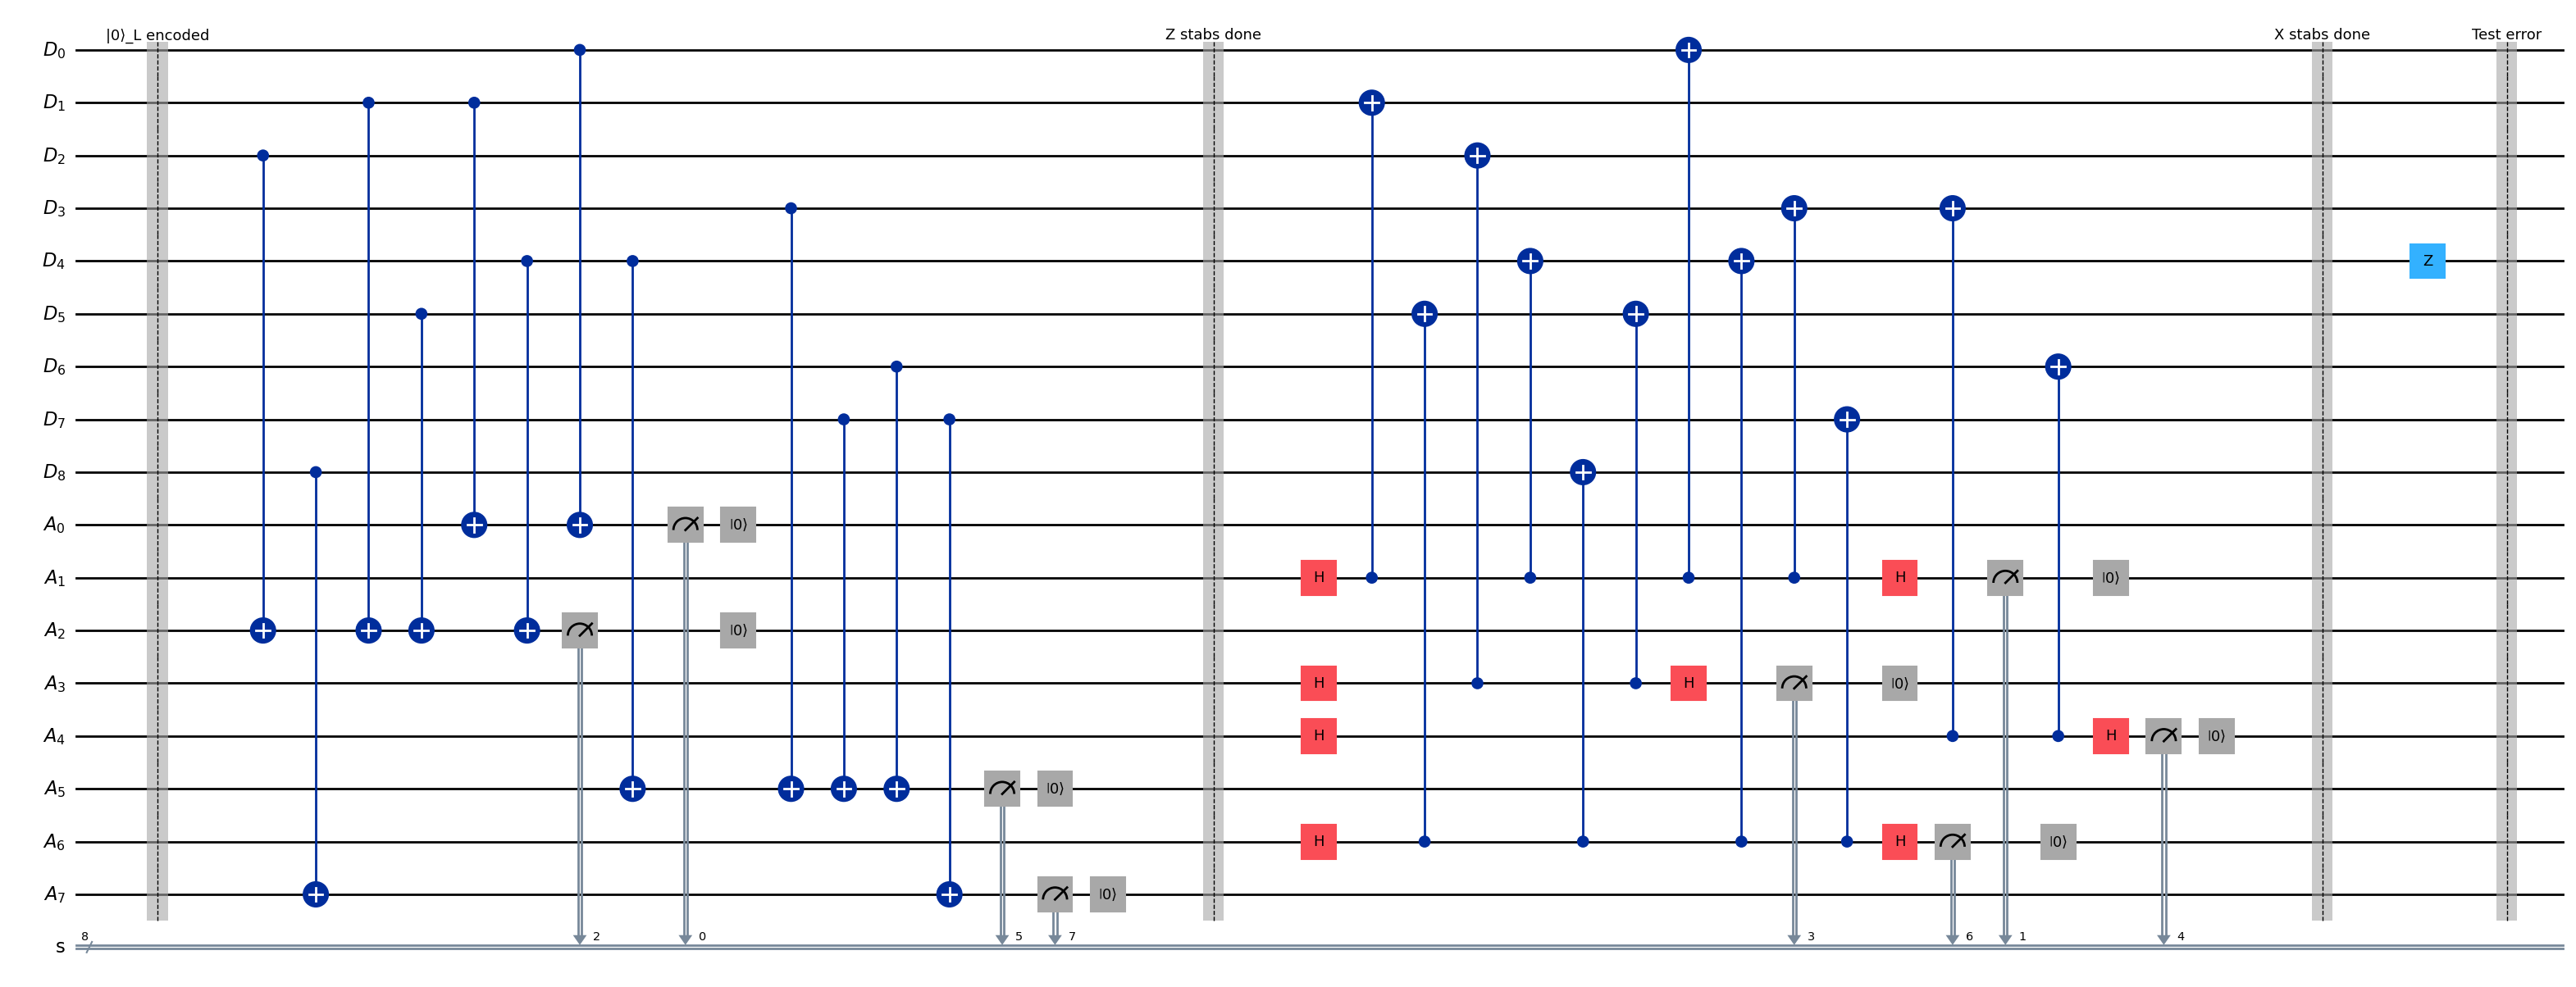

In [ ]:
# STEP 7 — Visualize
# ============================================================
qc.draw('mpl', fold=1)




In [ ]:
plot_histogram(counts, title="Rotated Surface Code Syndromes")
plt.show()